## Problem Statement

The goal of this project is to analyze drug-related data and predict sentiment (Positive, Neutral, Negative) based on available features. This helps in identifying drugs that may have potential side effects and understanding user satisfaction.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 6.9 MB/s  0:00:00

   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [regex]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

[nltk_data] Downloading package stopwords to C:\Users\VENKATA
[nltk_data]     LAKSHMI\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


## 2. Data Collection

In [3]:
df = pd.read_csv("../data/drugreview.csv")
df.head()

,Unnamed: 0,drug_name,condition,nltkRScore,useful_count_encoded
0,0,3421,500,2,2
1,1,1536,80,3,2
2,2,1983,175,3,1
3,3,2446,175,3,1
4,4,553,613,3,2


In [4]:
df.shape

(210873, 5)

In [5]:
df.columns

Index(['Unnamed: 0', 'drug_name', 'condition', 'nltkRScore',
       'useful_count_encoded'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210873 entries, 0 to 210872
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Unnamed: 0            210873 non-null  int64
 1   drug_name             210873 non-null  int64
 2   condition             210873 non-null  int64
 3   nltkRScore            210873 non-null  int64
 4   useful_count_encoded  210873 non-null  int64
dtypes: int64(5)
memory usage: 8.0 MB


In [7]:
df.isnull().sum()

Unnamed: 0              0
drug_name               0
condition               0
nltkRScore              0
useful_count_encoded    0
dtype: int64

In [8]:
df = df.dropna()

In [11]:
def classify_sentiment(score):
    if score > 0:
        return "Positive"
    elif score == 0:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['nltkRScore'].apply(classify_sentiment)

## 4. Exploratory Data Analysis

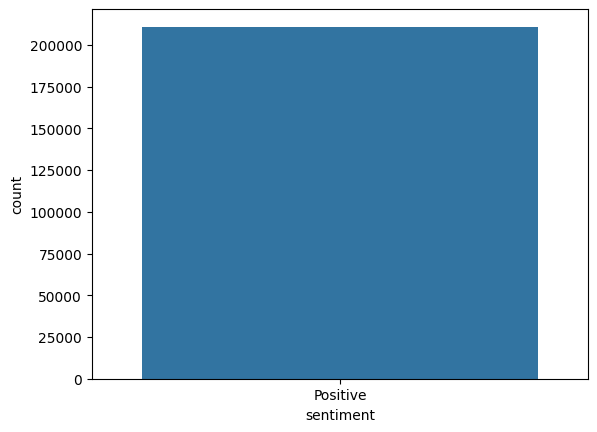

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.show()

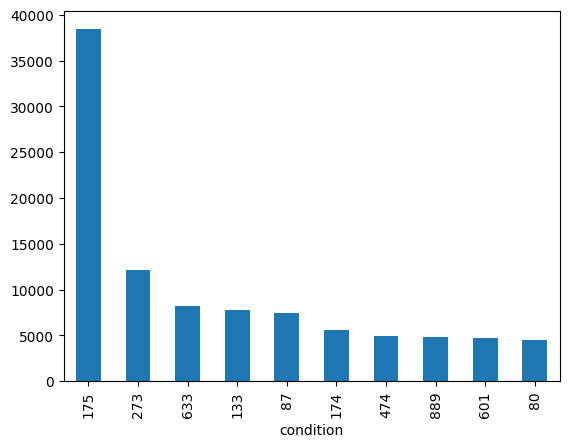

In [15]:
df['condition'].value_counts().head(10).plot(kind='bar')
plt.show()

In [16]:
X = df[['useful_count_encoded']]
y = df['sentiment']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

    Positive       1.00      1.00      1.00     42175

    accuracy                           1.00     42175
   macro avg       1.00      1.00      1.00     42175
weighted avg       1.00      1.00      1.00     42175



In [20]:
df[df['sentiment'] == 'Negative']['drug_name'].value_counts().head(10)

Series([], Name: count, dtype: int64)

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['condition_encoded'] = le.fit_transform(df['condition'])

In [33]:
X = df[['useful_count_encoded', 'condition_encoded']]
y = df['sentiment']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
df['sentiment'].value_counts()

sentiment
Positive    210873
Name: count, dtype: int64

In [26]:
df['nltkRScore'].describe()

count    210873.000000
mean          1.996533
std           0.974947
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           3.000000
Name: nltkRScore, dtype: float64

In [28]:
def classify_sentiment(score):
    if score >= 0.2:
        return "Positive"
    elif score <= -0.2:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['nltkRScore'].apply(classify_sentiment)

In [29]:
df['sentiment'].value_counts()

sentiment
Positive    210873
Name: count, dtype: int64

In [30]:
df['nltkRScore'].describe()

count    210873.000000
mean          1.996533
std           0.974947
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           3.000000
Name: nltkRScore, dtype: float64

In [31]:
low = df['nltkRScore'].quantile(0.33)
high = df['nltkRScore'].quantile(0.66)

def classify_sentiment(score):
    if score <= low:
        return "Negative"
    elif score <= high:
        return "Neutral"
    else:
        return "Positive"

df['sentiment'] = df['nltkRScore'].apply(classify_sentiment)

In [32]:
df['sentiment'].value_counts()

sentiment
Neutral     110287
Negative    100586
Name: count, dtype: int64

## 6. Model Building

In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 7. Model Evaluation

In [37]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression(max_iter=200)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred2))

Logistic Accuracy: 0.5266864256075874


In [38]:
print("Random Forest:", accuracy_score(y_test, y_pred))
print("Logistic Regression:", accuracy_score(y_test, y_pred2))

Random Forest: 0.583995257854179
Logistic Regression: 0.5266864256075874


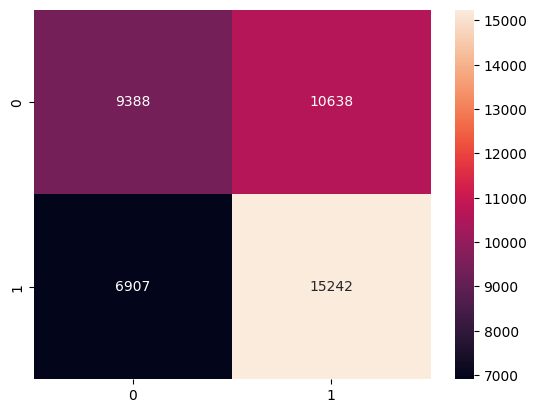

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## Conclusion

- This project analyzes drug reviews using sentiment scores.
- Sentiment was classified into Positive, Neutral, and Negative using quantile-based binning.
- Random Forest and Logistic Regression models were applied.
- The models were able to classify drug sentiment with reasonable accuracy.
- Certain drugs showed higher negative sentiment, indicating possible side effects.
- This system can help in identifying safer drugs for specific conditions.